In [9]:
import sqlite3
import pandas as pd

# Connect to SQLite database (it will create if it doesn't exist)
conn = sqlite3.connect('sales.db')

In [10]:
# Load CSV into a pandas DataFrame
data = pd.read_csv("sales.csv")

# Save it as a table called 'sales' in SQLite
data.to_sql('sales', conn, if_exists='replace', index=False)

7

In [11]:
query = """
SELECT Product, SUM(Quantity * Price) AS TotalSales
FROM sales
GROUP BY Product;
"""

df_total_sales = pd.read_sql(query, conn)
df_total_sales

,Product,TotalSales
0,WidgetA,150
1,WidgetB,20
2,WidgetC,75
3,WidgetD,300
4,WidgetE,100
5,WidgetF,60


In [12]:
query = """
SELECT CustomerID, SUM(Quantity * Price) AS TotalSpent
FROM sales
GROUP BY CustomerID
ORDER BY TotalSpent DESC
LIMIT 5;
"""

df_top_customers = pd.read_sql(query, conn)
df_top_customers

,CustomerID,TotalSpent
0,101,400
1,104,100
2,103,75
3,102,70
4,105,60


In [13]:
query = """
SELECT strftime('%Y-%m', OrderDate) AS Month, SUM(Quantity * Price) AS TotalSales
FROM sales
GROUP BY Month
ORDER BY Month;
"""

df_monthly_sales = pd.read_sql(query, conn)
df_monthly_sales

,Month,TotalSales
0,2023-01,495
1,2023-02,210


<Axes: title={'center': 'Monthly Sales'}, xlabel='Month'>

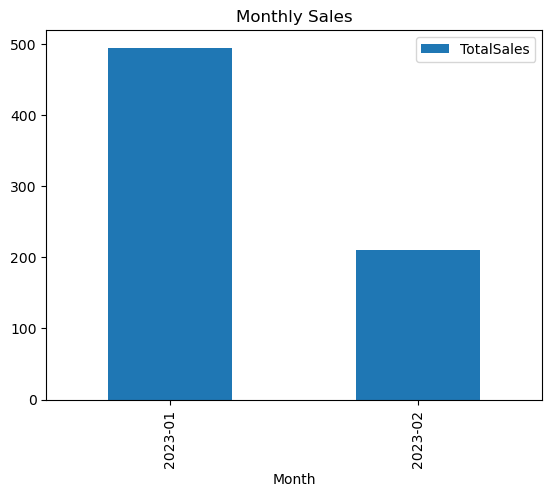

In [14]:
df_monthly_sales.plot(x='Month', y='TotalSales', kind='bar', title='Monthly Sales')